In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Loan_default.csv")

print("Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nUnique values:")
print(df.nunique())

print("\nDataset info:")
df.info()

Shape: (255347, 18)

First 5 rows:


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0



Data types:
LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

Missing values:
0

Unique values:
LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

Datase

In [26]:
df['Default'].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

In [27]:
print(df.nunique().sort_values())

HasMortgage            2
HasDependents          2
Default                2
HasCoSigner            2
MaritalStatus          3
Education              4
EmploymentType         4
NumCreditLines         4
LoanTerm               5
LoanPurpose            5
Age                   52
DTIRatio              81
MonthsEmployed       120
CreditScore          550
InterestRate        2301
Income            114620
LoanAmount        158729
LoanID            255347
dtype: int64


In [28]:
target_col = "Default"
id_col = "LoanID"

cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

num_cols.remove(target_col)

cat_cols.remove(id_col)

print("Categorical columns:")
print(cat_cols)

print("\nNumerical columns:")
print(num_cols)

Categorical columns:
['Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

Numerical columns:
['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']


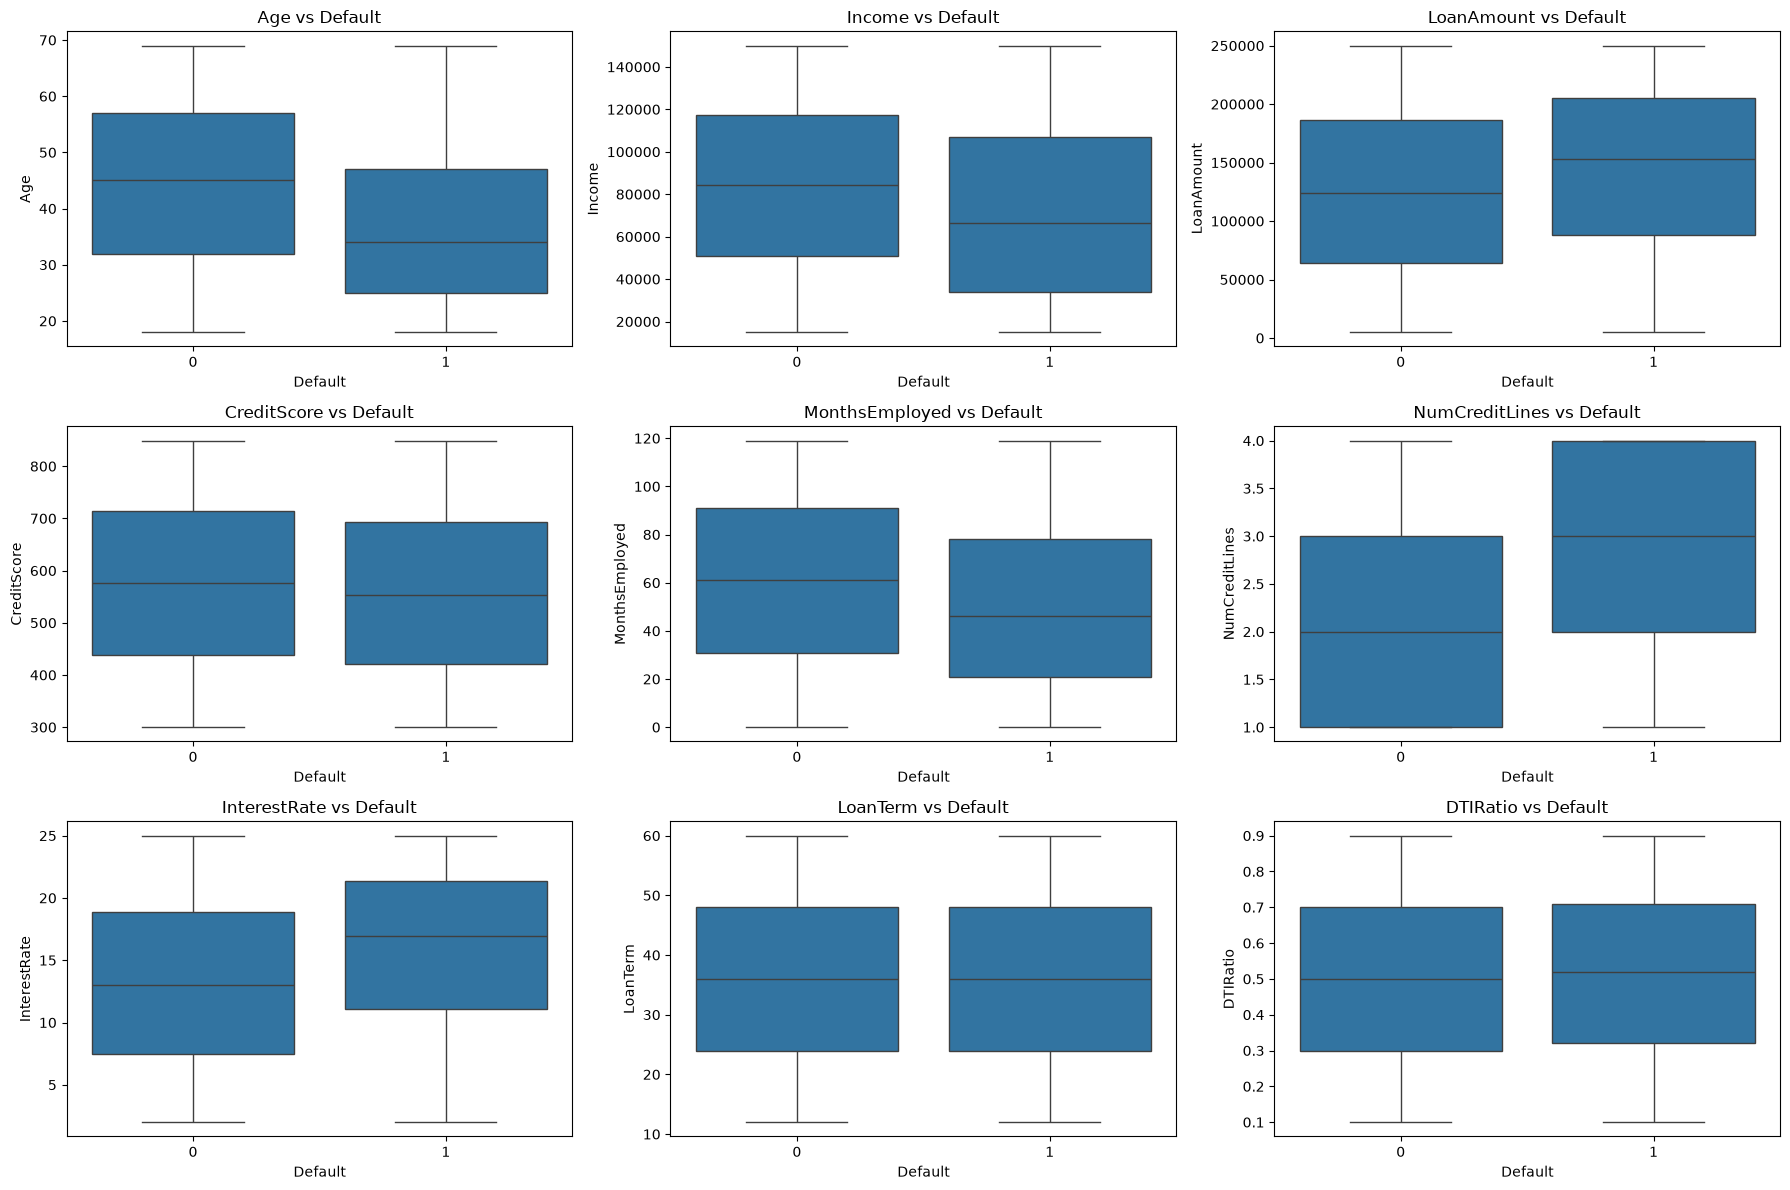

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="Default", y=col, ax=axes[i])
    axes[i].set_title(f"{col} vs Default")

plt.tight_layout()
plt.show()

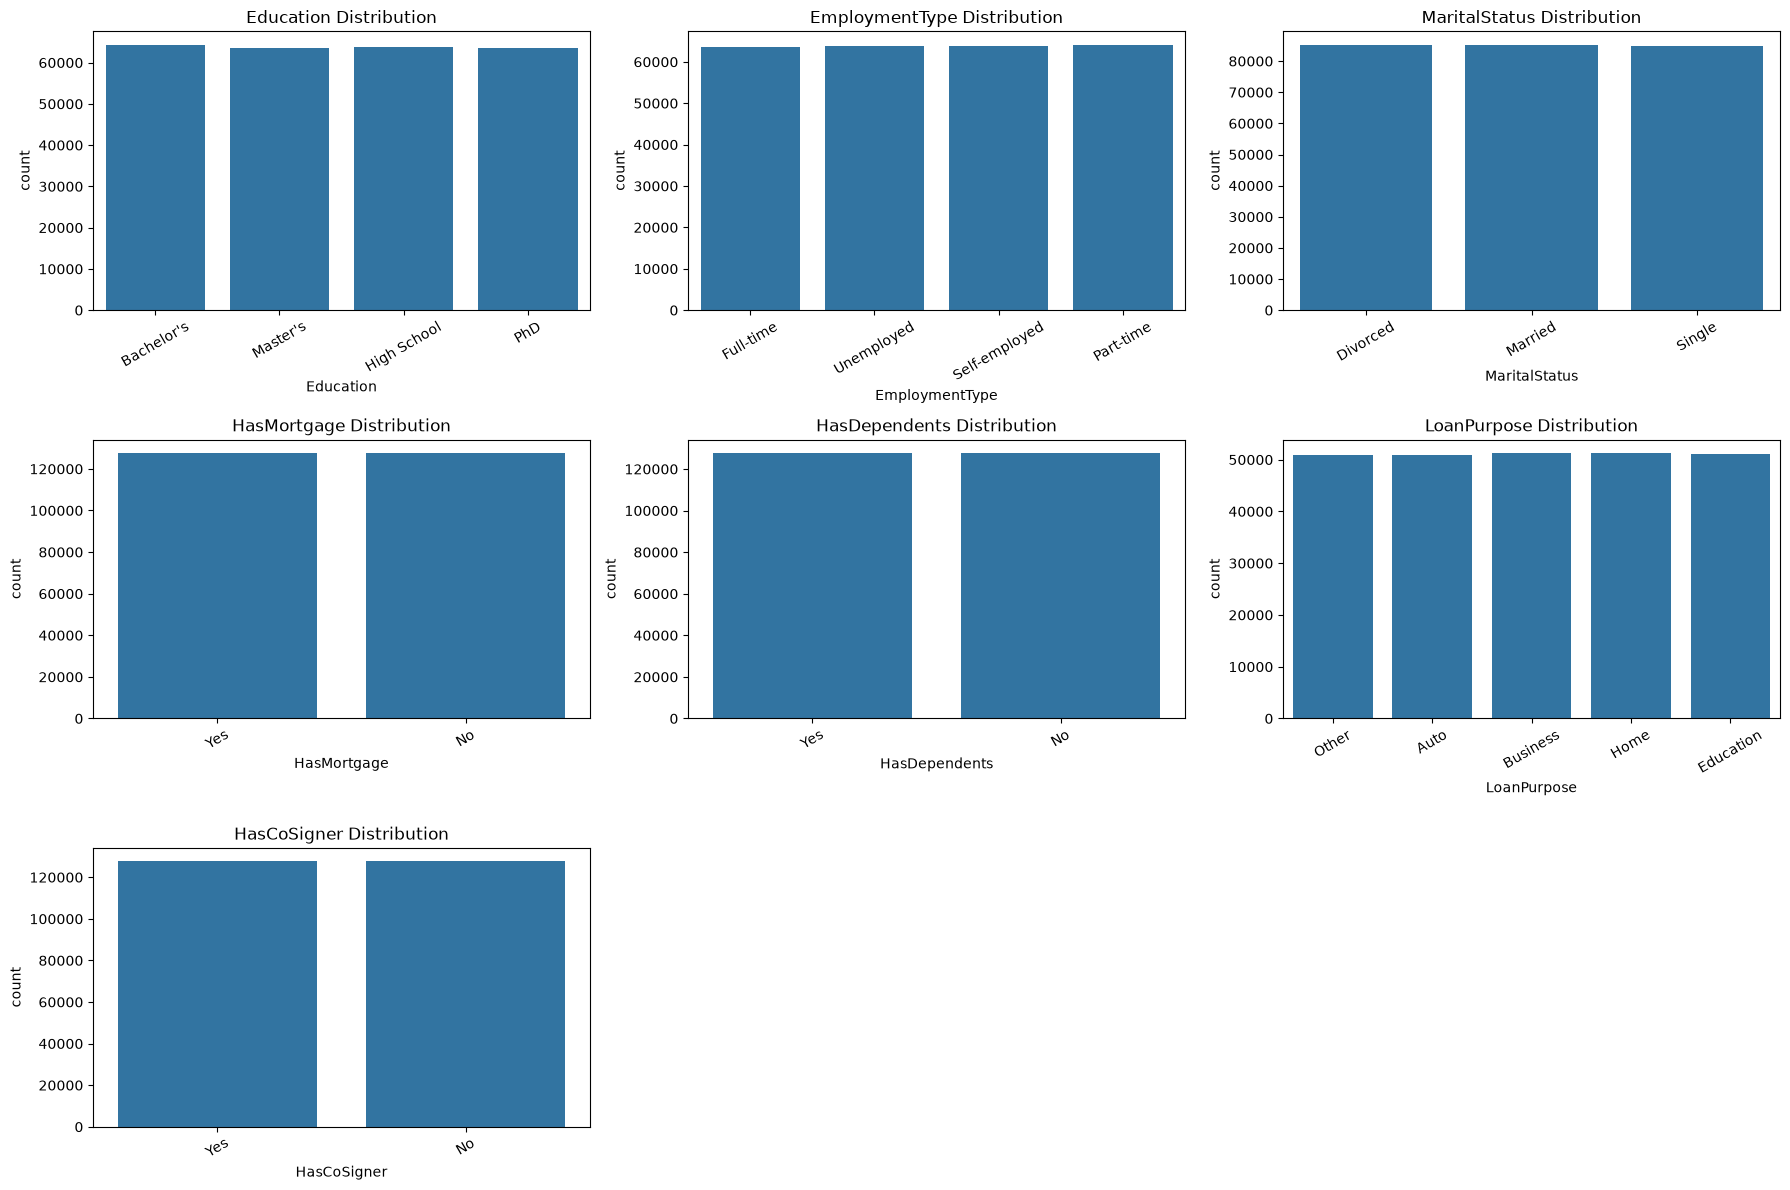

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f"{col} Distribution")
    axes[i].tick_params(axis="x", rotation=30)

for i in range(len(cat_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [31]:
df["Education"].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [32]:
df["EmploymentType"].value_counts()

EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

In [33]:
df["MaritalStatus"].value_counts()

MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

In [34]:
df["HasMortgage"].value_counts()

HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

In [35]:
df["HasDependents"].value_counts()

HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

In [36]:
df["LoanPurpose"].value_counts()

LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

In [37]:
df["HasCoSigner"].value_counts()

HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64

Education       → Ordinal
EmploymentType  → One-Hot
MaritalStatus   → One-Hot
HasMortgage     → Binary
HasDependents   → Binary
LoanPurpose     → One-Hot
HasCoSigner     → Binary

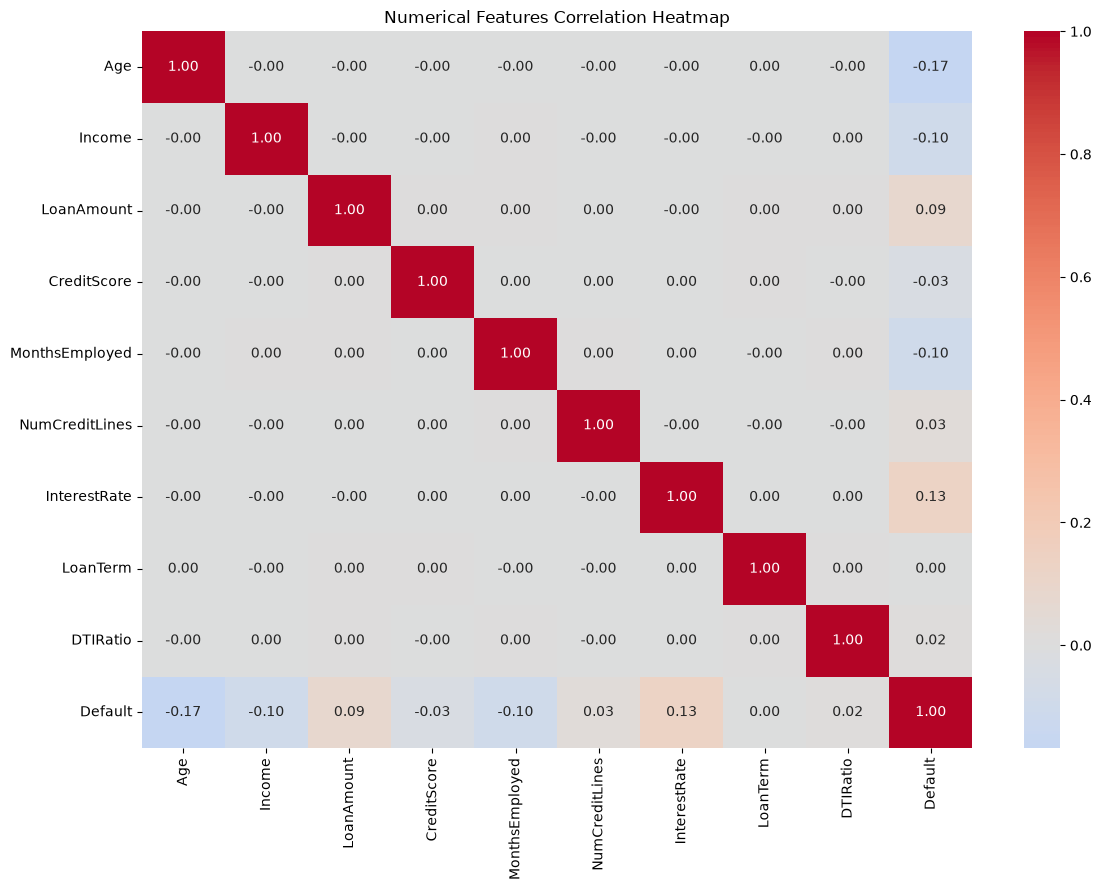

In [38]:
plt.figure(figsize=(12, 9))
corr = df[num_cols + ["Default"]].corr()
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Numerical Features Correlation Heatmap")
plt.tight_layout()
plt.show()

In [39]:
df[num_cols].corrwith(df["Default"]).sort_values(ascending=False)

InterestRate      0.131273
LoanAmount        0.086659
NumCreditLines    0.028330
DTIRatio          0.019236
LoanTerm          0.000545
CreditScore      -0.034166
MonthsEmployed   -0.097374
Income           -0.099119
Age              -0.167783
dtype: float64

In [40]:
skewness = df[num_cols].skew().sort_values(ascending=False)
print(skewness)

CreditScore       0.004688
InterestRate      0.004608
Age               0.000698
NumCreditLines   -0.000278
Income           -0.000381
DTIRatio         -0.001499
LoanAmount       -0.001827
MonthsEmployed   -0.002142
LoanTerm         -0.002178
dtype: float64


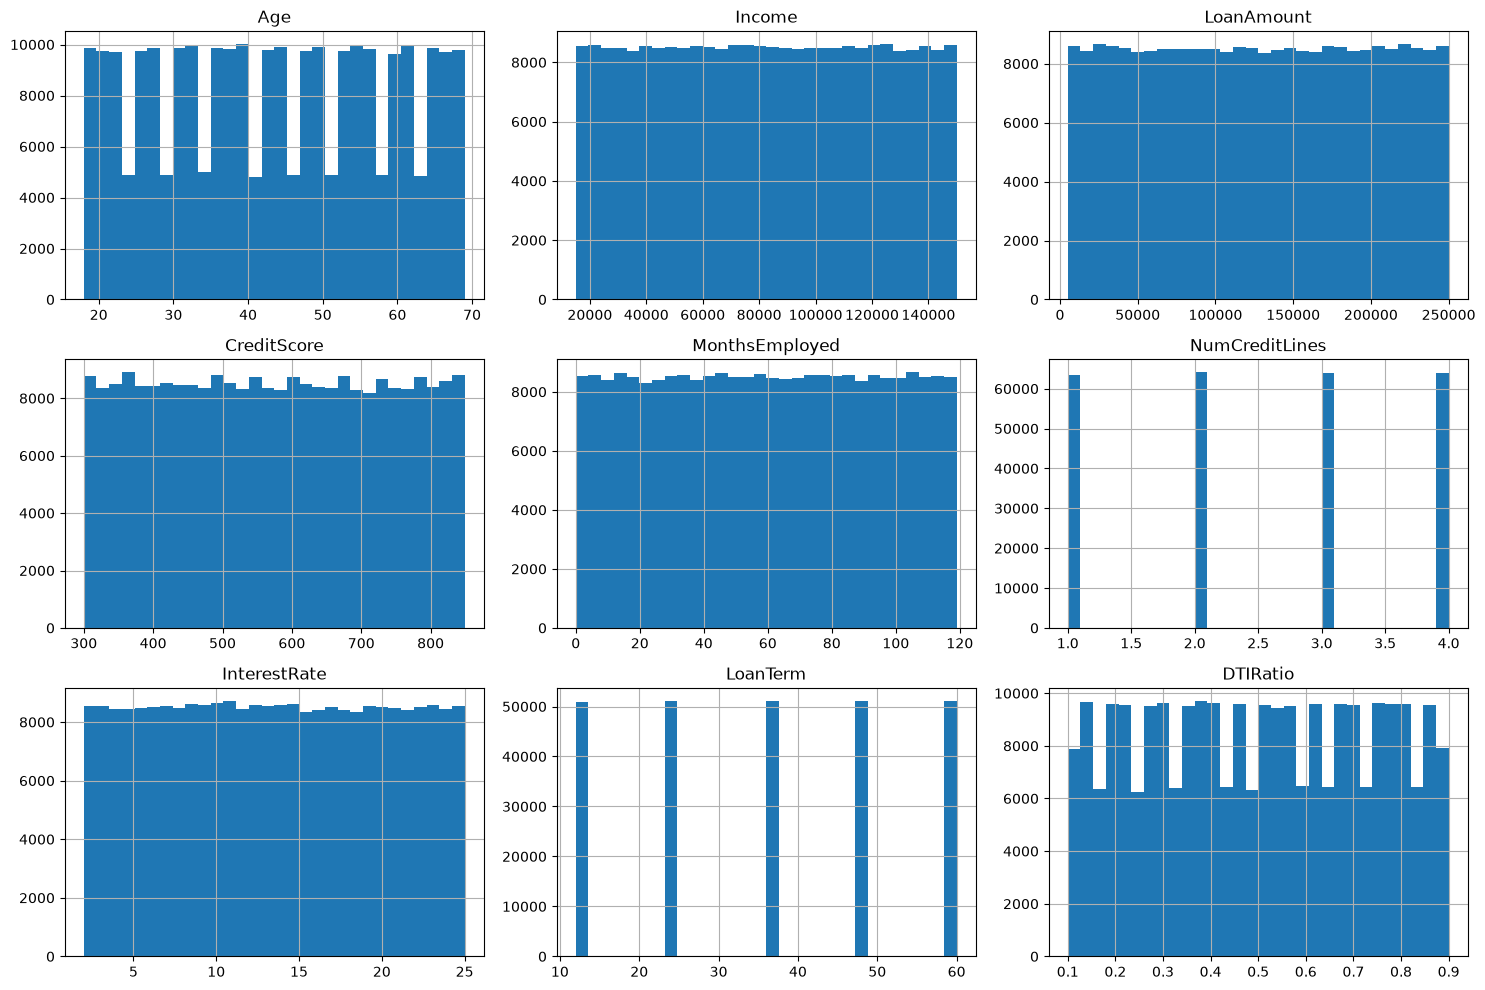

In [41]:
df[num_cols].hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [42]:
X = df.drop(columns=["Default", "LoanID"])
y = df["Default"]

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(204277, 16)
(51070, 16)
Default
0    0.883873
1    0.116127
Name: proportion, dtype: float64
Default
0    0.883865
1    0.116135
Name: proportion, dtype: float64


In [44]:
binary_cols = [
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

for col in binary_cols:
    X_train[col] = X_train[col].map({"No": 0, "Yes": 1})
    X_test[col] = X_test[col].map({"No": 0, "Yes": 1})

In [45]:
education_map = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "PhD": 3
}

X_train["Education"] = X_train["Education"].map(education_map)
X_test["Education"] = X_test["Education"].map(education_map)

In [46]:
from sklearn.preprocessing import OneHotEncoder

onehot_cols = [
    "EmploymentType",
    "MaritalStatus",
    "LoanPurpose"
]

encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

train_encoded = encoder.fit_transform(X_train[onehot_cols])
test_encoded = encoder.transform(X_test[onehot_cols])

In [47]:
encoded_cols = encoder.get_feature_names_out(onehot_cols)

X_train[encoded_cols] = train_encoded
X_test[encoded_cols] = test_encoded

X_train.drop(columns=onehot_cols, inplace=True)
X_test.drop(columns=onehot_cols, inplace=True)

print(X_train.shape)
print(X_test.shape)

(204277, 22)
(51070, 22)


In [48]:
print(X_train.dtypes.value_counts())
print(X_train.isnull().sum().sum())

int64      11
float64    11
Name: count, dtype: int64
0


In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(204277, 22)
(51070, 22)


In [51]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

print(results_df.round(4))

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
                 Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  Logistic Regression    0.6761     0.2194  0.6995  0.3341   0.7532  0.3105
1        Random Forest    0.8801     0.4517  0.1521  0.2275   0.7477  0.3098
2          Extra Trees    0.8843     0.6949  0.0069  0.0137   0.7432  0.3009
3        Decision Tree    0.8165     0.2071  0.2052  0.2061   0.5510  0.1348


In [53]:

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

model = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    random_state=42
)

param_grid = {
    "C": np.logspace(-4, 3, 40),
    "solver": ["liblinear", "lbfgs"],
    "fit_intercept": [True, False],
    "class_weight": ["balanced", None],
    "max_iter": [1000, 2000, 3000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=50,
    scoring="average_precision",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train_scaled, y_train)
best_model = random_search.best_estimator_

y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob)
}

print("Best Params:", random_search.best_params_)
print(pd.Series(results).round(4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Params: {'solver': 'lbfgs', 'max_iter': 2000, 'fit_intercept': False, 'class_weight': None, 'C': np.float64(0.25719138090593446)}
Accuracy     0.5683
Precision    0.1865
Recall       0.8085
F1           0.3031
ROC-AUC      0.7530
PR-AUC       0.3116
dtype: float64

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.54      0.69     45139
           1       0.19      0.81      0.30      5931

    accuracy                           0.57     51070
   macro avg       0.57      0.67      0.50     51070
weighted avg       0.87      0.57      0.64     51070

Confusion Matrix:
[[24228 20911]
 [ 1136  4795]]


In [54]:
from sklearn.metrics import precision_recall_curve
y_prob = random_search.best_estimator_.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1 = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

idx = np.argmax(f1)

best_threshold = thresholds[idx]

print("Best Threshold:", round(best_threshold, 4))
print("Precision:", round(precision[idx], 4))
print("Recall:", round(recall[idx], 4))
print("F1:", round(f1[idx], 4))

Best Threshold: 0.5745
Precision: 0.2793
Recall: 0.5348
F1: 0.367


In [55]:
y_pred = (y_prob >= best_threshold).astype(int)

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.7857
Precision: 0.2793
Recall   : 0.5348
F1       : 0.367
ROC-AUC  : 0.753
PR-AUC   : 0.3116

Confusion Matrix:
[[36955  8184]
 [ 2759  3172]]


In [56]:
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

models = {
    "CatBoost": CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        verbose=False,
        random_seed=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    "PR-AUC",
    ascending=False
)

print(results_df.round(4))

Training CatBoost...
Training XGBoost...
      Model  Accuracy  Precision  Recall      F1  ROC-AUC  PR-AUC
0  CatBoost    0.8867     0.6113  0.0676  0.1218   0.7597  0.3324
1   XGBoost    0.8861     0.5780  0.0700  0.1248   0.7545  0.3251


In [57]:
from sklearn.metrics import precision_recall_curve

cat_prob = models["CatBoost"].predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    cat_prob
)

f1 = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

idx = np.argmax(f1)

cat_threshold = thresholds[idx]

print("Best Threshold:", round(cat_threshold, 4))
print("Precision:", round(precision[idx], 4))
print("Recall:", round(recall[idx], 4))
print("F1:", round(f1[idx], 4))

Best Threshold: 0.1859
Precision: 0.3068
Recall: 0.4842
F1: 0.3756


In [58]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cat_model = CatBoostClassifier(
    verbose=False,
    random_seed=42
)

param_grid = {
    "iterations": [300, 500, 700, 1000],
    "depth": [4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "random_strength": [0, 0.5, 1, 2]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cat_search = RandomizedSearchCV(
    cat_model,
    param_distributions=param_grid,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cat_search.fit(X_train, y_train)

print("Best Params:")
print(cat_search.best_params_)

print(
    "Best CV PR-AUC:",
    round(cat_search.best_score_, 4)
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Params:
{'subsample': 0.7, 'random_strength': 2, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'iterations': 700, 'depth': 4}
Best CV PR-AUC: 0.324


In [59]:
best_cat = cat_search.best_estimator_

cat_prob = best_cat.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, cat_prob), 4))
print("PR-AUC :", round(average_precision_score(y_test, cat_prob), 4))

ROC-AUC: 0.7606
PR-AUC : 0.335


In [60]:
precision, recall, thresholds = precision_recall_curve(
    y_test, cat_prob
)

f1 = 2 * (precision[:-1] * recall[:-1]) / (
    precision[:-1] + recall[:-1] + 1e-10
)

idx = np.argmax(f1)

threshold = thresholds[idx]

y_pred = (cat_prob >= threshold).astype(int)

print("Threshold:", round(threshold, 4))
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1       :", round(f1_score(y_test, y_pred), 4))

Threshold: 0.1804
Accuracy : 0.8073
Precision: 0.302
Recall   : 0.5026
F1       : 0.3773
